# Tablo Verisi ile İlk Model Eğitimi (Regresyon)

**Proje:** AI Destekli Cepte Veterinerlik

**Bu notebook'un amacı:** İlk kez sıfırdan bir makine öğrenmesi modeli eğitmek.
Bu turda amaç yüksek doğruluk değil, model eğitiminin tüm aşamalarını (veriyi
tanıma → bölme → model kurma → eğitme → değerlendirme → tahmin) bir kez baştan
sona öğrenmek.

Basit ve temiz bir veri seti kullanıyorum ki tek bir şeye odaklanabileyim:
model eğitiminin mantığı. Buradaki regresyon mantığı (sayısal bir değeri tahmin
etme), ileride projedeki **hayvan verim/kilo tahmini** özelliğinin temelini
oluşturacak.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

veri = fetch_california_housing()
df = pd.DataFrame(veri.data, columns=veri.feature_names)
df["FiyatHedef"] = veri.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,FiyatHedef
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


***burada öncelikle sklearn kütüphanesinden hazır bir veri seti çağırıyoruz.

***Tablolarla çalışacağımız için de "pandas"ı kullanıyoruz."as pd" demek bundan sonra panda yerine pd kullanacağım demek bunu da dipnot geçiyim.

***californi-housing bun iş için baslangıc en temiz yöntem oldugu için bunu import ediyoruz.

***veri=fetck_california_housing() burda da veri setini indirip verinin içine koyuyoruz.

***DataFrame()=nu veri tablosu demek.Yani "df=pd.DataFrame" bu kod pandas'dan veri tablomu çekip gösteriyorum demek gibi bi şey.

***tabloya modelin tahmin etmesini istediğimiz fiyat sütununu ekliyoruz target ile beraber.

***df.head() bu kod da bizim ilk 5 satırımızı göstermemizi sağlıyor diyebiliriz.

In [2]:
print("Satır ve sütun sayısı:", df.shape)
print()

df.info()
print()

df.describe()

Satır ve sütun sayısı: (20640, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   FiyatHedef  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,FiyatHedef
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


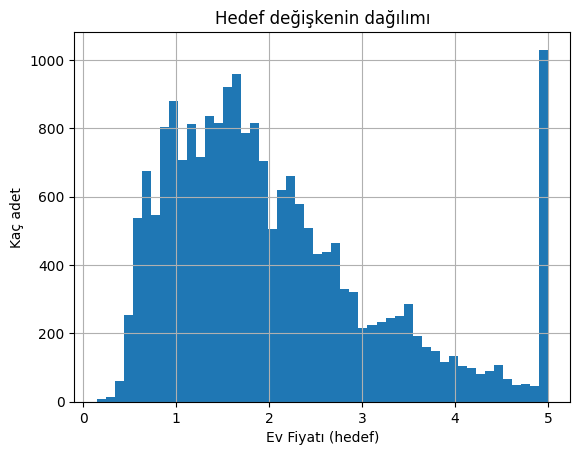

In [3]:
import matplotlib.pyplot as plt

df["FiyatHedef"].hist(bins=50)
plt.xlabel("Ev Fiyatı (hedef)")
plt.ylabel("Kaç adet")
plt.title("Hedef değişkenin dağılımı")
plt.show()

Bu hücre veriyi "görsel olarak" tanımamızı sağlıyor

import matplotlib.pyplot as plt — matplotlib, Python'da grafik çizmenin en temel kütüphanesi. as plt yine standart kısaltması. Sayılara tablo halinde bakmak bir şeydir


df["FiyatHedef"].hist(bins=50) — hedef sütunumuzun (ev fiyatı) bir histogramını çiziyoruz. Histogram şu demek: "hangi fiyat aralığında kaç ev var?" Yani fiyatların nasıl dağıldığını gösteren bir çubuk grafik. bins=50 de "fiyat aralığını 50 parçaya böl" demek —


Alttaki plt.xlabel, plt.ylabel, plt.title satırları grafiğe etiket koyuyor: yatay eksen ne, dikey eksen ne, başlık ne.

plt.show() — grafiği ekrana bas.

bunu niye yapıyoruz diye sorgulayacak olursak sebebi şu:

da-ğılımları görselle görmek daha faydalı çünkü keskin bi dağılım var mı,dengeli mi dengesiz mi?

bunları bu sekilde görmel ilerde projede bize "verim" ya da "kilo" hakkında fikir sahibi olammızı sağlayacak ve yorumlayabileceğiz.tespit yapmamıza yardımcı olucak.


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("FiyatHedef", axis=1)
y = df["FiyatHedef"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim verisi:", X_train.shape)
print("Test verisi:", X_test.shape)

Eğitim verisi: (16512, 8)
Test verisi: (4128, 8)


Önce X = df.drop("FiyatHedef", axis=1) ve y = df["FiyatHedef"] — veriyi ikiye ayırıyoruz. X (büyük harf, gelenek böyle) özellikler, yani modele vereceğimiz girdiler — evin tüm bilgileri, ama fiyat hariç. drop "çıkar/at" demek, yani "fiyat sütununu çıkar, gerisi X olsun." y ise hedef, yani tahmin etmek istediğimiz fiyat. Model X'e bakıp y'yi tahmin etmeyi öğrenecek.

kritik satır, train_test_split(...) — veriyi eğitim ve test diye ikiye bölüyoruz. test_size=0.2 demek "verinin %20'sini teste ayır, %80'ini eğitime.(test_size=0.2 olmasının temel nedeni 100 ünü de teste alırsan model hepsiyle eğitilmiş olur yani cevap verirken kopya çekmiş olur sonuc tamamen dogru cıkar ama hiç bi şey öğrenmemiş olur bu da bizim hiç bi işimize tyaramaz dogruluk kısmen düşebibilir faket egitim süreci basarılı bi şekilde ilerlemiş olurrr :))

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model eğitildi!")

Model eğitildi!


from sklearn.linear_model import LinearRegression — scikit-learn'den LinearRegression (doğrusal regresyon) adlı modeli çağırıyoruz.(bunu seçmemizin nedeni basit ve anlaşılır olması diyebiliriz)

model = LinearRegression() — modeli oluşturup model adlı kutuya koyuyoruz.

model.fit(X_train, y_train) — fit yani "eğit/uydur". Bütün ML burada oluyor. Modele diyoruz ki: "İşte sana eğitim verisi — bu evlerin özellikleri (X_train) ve gerçek fiyatları (y_train). Bunlara bak ve aralarındaki ilişkiyi öğren." Model bu satırda eğitim verisini defalarca inceleyip o "çizgiyi", o ilişkiyi buluyor. Bu satır çalıştıktan sonra artık model cahil değil — bir şeyler öğrenmiş, tahmin yapabilecek hale gelmiş



In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

tahminler = model.predict(X_test)

mae = mean_absolute_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print("Ortalama Mutlak Hata (MAE):", round(mae, 3))
print("R² skoru:", round(r2, 3))

Ortalama Mutlak Hata (MAE): 0.533
R² skoru: 0.576


`tahminler = model.predict(X_test)` — işte modeli sınava soktuğumuz satır. predict yani "tahmin et". Modele diyoruz ki: "İşte hiç görmediğin test evleri (X_test), bunların fiyatını tahmin et." Model öğrendiği ilişkiyi kullanıp her ev için bir fiyat tahmini üretiyor, hepsini tahminler kutusuna koyuyor. Dikkat: burada modele doğru cevapları vermedik — sadece özellikleri verdik, o kendi tahminini yaptı. Gerçek fiyatlar (y_test) elimizde ama kilitli, birazdan karşılaştırmak için kullanacağız.(bu da test_size=0.2 sayesinde ve modeli eğitirken diğerlerini kilitlemiş olmamız sayesinde olmuş oldu yani)

`mean_absolute_error(y_test, tahminler)` — MAE, Ortalama Mutlak Hata. Mantığı çok sezgisel: modelin her tahminini gerçek fiyatla karşılaştırıp "ne kadar yanılmış?" diye bakıyor, sonra bunların ortalamasını alıyor. Yani "model ortalama olarak şu kadar yanılıyor" der. Bu veri setinde fiyatlar yüz binlerce dolar cinsinden ölçekli, o yüzden mesela 0.53 gibi bir sayı görürsen "ortalama 53 bin dolar yanılıyor" demek. Ne kadar küçükse o kadar iyi — sıfır olsa kusursuz olurdu (ama asla olmaz).



`(r2_score(y_test, tahminler)` — R² skoru. Bu biraz farklı: "model, fiyatlardaki değişimin ne kadarını açıklayabiliyor?" diye ölçer. 0 ile 1 arası bir sayı; 1'e ne kadar yakınsa o kadar iyi. Mesela 0.60 görürsen "model fiyat farklılıklarının %60'ını yakalayabiliyor, %40'ı hâlâ açıklanamıyor" demek. Bu sana modelin genel gücünü tek bir sayıyla verir.bu da gayet faydalı ve sağlıklı)





In [8]:
import joblib

joblib.dump(model, "ev_fiyat_modeli.pkl")
print("Model dosyaya kaydedildi.")

yeni_ev = X_test.iloc[[0]]
tahmin = model.predict(yeni_ev)

print("\nGerçek fiyat:", y_test.iloc[0])
print("Modelin tahmini:", round(tahmin[0], 3))

Model dosyaya kaydedildi.

Gerçek fiyat: 0.477
Modelin tahmini: 0.719


`joblib.dump` ile eğittiğimiz modeli bir dosyaya kaydediyoruz. Peki bu neden
önemli? Model kaybolmasın ve notebook'u tekrar açtığımızda her şeye baştan
başlamayalım diye. `.pkl` olarak kaydederiz ve istediğimiz yerde, yeniden
eğitmeye gerek kalmadan çalışır halde kullanabiliriz.

`yeni_ev = X_test.iloc[[0]]` — bu kodun amacı, test verisinden tek bir ev alıp
onu modele sormak.

`tahmin = model.predict(yeni_ev)` — bu kodda model o tek ev için fiyat tahmini
yapıyor.

Bunun bize sağlayacağı fayda şu: bir hayvanın özelliklerini modele verirsin,
model "bu hayvan şu kadar verim/kilo yapar" der, sen de gerçek değerle
karşılaştırırsın. Tam olarak bu mantık.



## 🎯 Kapanış — Bu Notebook Bir Antrenman Turuydu

Bu notebook, projenin bir parçası değil; **bir öğrenme / antrenman çalışmasıdır.**
Amacım, ilk kez sıfırdan bir makine öğrenmesi modeli eğitmenin tüm aşamalarını
uçtan uca öğrenmekti.

Bunun için gerçek proje verisi yerine, temiz ve hazır bir veri seti olan
**California Housing**'i kullandım. Böylece tek bir şeye odaklanabildim: model
eğitiminin mantığı.

### Bu turda öğrendiğim adımlar (ML boru hattı)
1. **Veriyi tanıma** — `shape`, `info`, `describe`, histogram ile veriye bakmak
2. **Veriyi bölme** — eğitim ve test olarak ayırmak (modelin ezber yapmasını önlemek)
3. **Model kurma ve eğitme** — `LinearRegression` + `fit`
4. **Değerlendirme** — MAE ve R² skorlarıyla ölçmek
5. **Kaydetme** — modeli `joblib` ile dosyaya kaydetmek
6. **Tahmin** — tek bir örnek üzerinde `predict` çalıştırmak

### Bu antrenman projeye nasıl bağlanıyor?
Buradaki **regresyon mantığı** (sayısal bir değeri tahmin etme), ileride projedeki
**hayvan verim/kilo tahmini** özelliğinin temelini oluşturacak. Kod iskeleti
büyük ölçüde aynı kalacak; sadece veri (ev → hayvan) ve hedef (fiyat → verim)
değişecek.

> Not: Bu bir alıştırmadır. Asıl proje ML çalışması, aynı yöntemin kendi hayvan
> verisi üzerinde uygulanmasıyla ayrı notebook'larda yapılacaktır.